In [ ]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from xgboost import XGBClassifier, XGBRegressor
from scipy import stats
import matplotlib.pyplot as plt

In [ ]:
# read in cleaned and merged mimic data, with engineered features
df = pd.read_csv('dummy_data/cleaned_data.csv')

In [23]:
df.head()

,subject_id,hadm_id,admission_type,admission_location,insurance,language,marital_status,race,hospital_expire_flag,ccs_seq,...,hour_cos,dow_sin,dow_cos,mon_sin,mon_cos,admission_index,days_since_prev_admission,days_since_first_admission,num_prior_admissions,has_prior_admission
0,10000690,26504700,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['CIR019', 'CIR019', 'CIR019', 'CIR003', 'CIR0...",...,8.660254e-01,-0.433884,-0.900969,1.224647e-16,-1.000000e+00,0,0.000000,0.000000,0,0
1,10000690,23280645,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['CIR019', 'CIR019', 'RSP002', 'CIR017', 'END0...",...,2.588190e-01,0.974928,-0.222521,-8.660254e-01,-5.000000e-01,1,71.170833,75.709722,1,1
2,10000690,25860671,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['RSP010', 'CIR019', 'RSP012', 'RSP012', 'GEN0...",...,-1.836970e-16,0.000000,1.000000,-8.660254e-01,5.000000e-01,2,39.175000,122.636111,2,1
3,10000690,26146595,EW EMER.,EMERGENCY ROOM,Medicare,English,WIDOWED,WHITE,0,"['DIG012', 'DIG012', 'DIG012', 'GEN002', 'CIR0...",...,9.659258e-01,-0.433884,-0.900969,0.000000e+00,1.000000e+00,3,442.413194,574.870833,3,1
4,10001919,29897682,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Private,English,MARRIED,OTHER,0,"['NEO013', 'NEO070', 'CIR033', 'DIG024', 'XXX0...",...,1.000000e+00,0.433884,-0.900969,1.000000e+00,6.123234e-17,0,0.000000,0.000000,0,0


In [59]:
df["admission_duration"].describe()

count    11828.000000
mean         4.889202
std          7.554199
min          0.006250
25%          1.110069
50%          2.821528
75%          5.687500
max        207.152778
Name: admission_duration, dtype: float64

In [ ]:
# Custom transformer to handle multi-label categorical features
# takes a column containing multiple labels (e.g. strings, lists, sets etc) 
# normalises the labels and one hot encodes them 

# baseestimator and transformermixin are sklearn classes that allow you to create custom transformers that can be used in sklearn pipelines
# basestimator is the base class for all estimators in sklearn
# transformermixin is a mixin class that provides a default implementation of the fit_transform method
# multilabelbinarizer is a sklearn class that allows you to one hot encode multi-label

class MLBBinarizer(BaseEstimator, TransformerMixin):
    def __init__(self, missing_literal="MISSING", sep=None):
        self.missing_literal = missing_literal # string used if data is missing
        self.sep = sep # separator used to split strings
        self.mlb_ = MultiLabelBinarizer() # sklearn multilabelbinarizer instance

    def _row_to_iterable(self, x):
        if pd.isna(x):
            return [self.missing_literal] # handle NaN values

        # Already-encoded strings like "MISSING" or "A,B" or "['A','B']"
        if isinstance(x, str):
            s = x.strip() # strip whitespace
            if not s:
                return [self.missing_literal] # handle empty strings
            # strip out brackets and quotes
            for ch in ['[', ']', '"', "'"]:
                s = s.replace(ch, '')
            # split string into parts based on separator
            # if a separator is provided, use it
            # otherwise, try comma first, then whitespace
            if self.sep is not None:
                parts = [p.strip() for p in s.split(self.sep) if p.strip()]
            else:
                parts = [p.strip() for p in s.split(',') if p.strip()]
                if len(parts) <= 1:
                    parts = [p.strip() for p in s.split() if p.strip()]
            return parts if parts else [self.missing_literal]

        # Already a list, tuple, or set
        if isinstance(x, (list, tuple, set)):
            return list(x) if len(x) else [self.missing_literal]

        # if not a string, list, tuple, or set, convert to string and process as above
        s = str(x).strip()
        if not s:
            return [self.missing_literal]
        for ch in ['[', ']', '"', "'"]:
            s = s.replace(ch, '')
        parts = [p.strip() for p in s.split(',') if p.strip()]
        if len(parts) <= 1:
            parts = [p.strip() for p in s.split() if p.strip()]
        return parts if parts else [self.missing_literal]

    def fit(self, X): #function to fit the transformer to the data
        seqs = [self._row_to_iterable(v) for v in np.ravel(X)] #convert each row to an iterable
        self.mlb_.fit(seqs) # fit the multilabelbinarizer to the data
        return self # return the fitted transformer

    def transform(self, X): #function to transform the data based on fitted transformer
        seqs = [self._row_to_iterable(v) for v in np.ravel(X)] # convert each row to an iterable
        return self.mlb_.transform(seqs) # return the one hot encoded data

    def get_feature_names_out(self): #function to get the feature names of the transformed data
        return np.array([f"ccs_{cls}" for cls in self.mlb_.classes_])

In [ ]:
### Mortality Prediction Task (Classification) ###

# Define data preprocessing functions

# Define columns for stratified split
ID_COLS = ['subject_id', 'hadm_id'] 
# Define target column
TARGET = 'hospital_expire_flag' 

# Define categorical, numeric, and sequence columns
categorical_cols = [ 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'race', 'gender', 'anchor_year_group']
numeric_cols = ['admission_duration', 'ed_duration', 'age_at_admission', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos', 'admission_index', 'days_since_prev_admission', 'days_since_first_admission', 'num_prior_admissions', 'has_prior_admission', 'ccs_seq_len' ] 
sequence_col = ['ccs_seq'] # single column, but ColumnTransformer expects a list

# Build preprocessing pipeline
# one hot encoding for cateogorical variables
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

#skip for numeric variables, they just need to be scaled
num_pipe = 'passthrough'  # keep as-is

#multilabelbinarizer for ccs sequence column 
seq_pipe = Pipeline(steps=[
    ('mlb', MLBBinarizer(missing_literal='MISSING'))
])

# Combine all preprocessing steps for each type of data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_cols),
        ('num', num_pipe, numeric_cols),
        ('seq', seq_pipe, sequence_col),
    ],
    remainder='drop',
    sparse_threshold=0.3
)

In [ ]:
#best parameters from hyperparameter tuning with grid search
best_params = {'colsample_bytree': np.float64(0.6733618039413735), # subsample ratio of columns when constructing each tree
 'gamma': np.float64(0.6084844859190754), # minimum loss reduction to make a further partition on a leaf node of the tree
 'learning_rate': np.float64(0.11445615769380281), # step size shrinkage used in update to prevents overfitting
 'max_depth': 6, # maximum depth of a tree
 'min_child_weight': 1, # minimum sum of instance weight (hessian) needed in a child
 'n_estimators': 1984, # number of trees to fit
 'reg_alpha': np.float64(0.5247746602583891), # L1 regularization term on weights
 'reg_lambda': np.float64(1.1995829151457664), # L2 regularization term on weights
 'subsample': np.float64(0.6186662652854461)} # subsample ratio of the training instances

In [ ]:
# Test-train split

# Collapse to patient-level labels for stratified splitting
patient_labels = (
    df.groupby("subject_id")["hospital_expire_flag"]
      .max()  # if any admission flagged death, mark as 1
      .reset_index()
)

# Define features and target for stratification
X = patient_labels["subject_id"]
y = patient_labels["hospital_expire_flag"]

# stratified split by patient_id and label
# split patient ids (makes sure all admissions are part of the same split to prevent data leakage)
# stratify by label to ensure that both train and test sets have the same proportion of mortality labels
train_ids, test_ids, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 80-20 train-test split
    random_state=42, # for reproducibility
    stratify=y  # Ensures same proportion of outcome classes based on mortality label
)

# assign admissions back to splits
train_df = df[df["subject_id"].isin(train_ids)] 
test_df  = df[df["subject_id"].isin(test_ids)]
y_train = df[df["subject_id"].isin(train_ids)]['hospital_expire_flag']
y_test = df[df["subject_id"].isin(test_ids)]['hospital_expire_flag']


print(train_df.shape, test_df.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))
#proportion of positive class (mortality) is similar in both train and test sets

(9577, 29) (2251, 29)
hospital_expire_flag
0    0.977133
1    0.022867
Name: proportion, dtype: float64
hospital_expire_flag
0    0.975566
1    0.024434
Name: proportion, dtype: float64


In [39]:
len(y_train)

9577

c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['INJ062', 'INJ063', 'MBD027', 'NEO001', 'NEO036', 'NEO059', 'NEO067'] will be ignored
  warnings.warn(


AUC-ROC=0.971  AUCPR=0.551  F1@thr=0.559 (thr≈0.400)


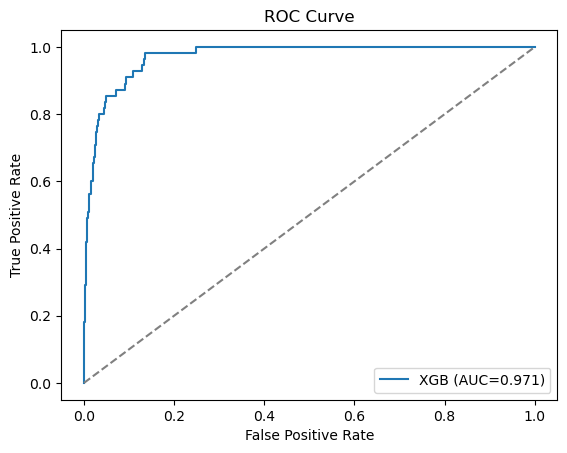

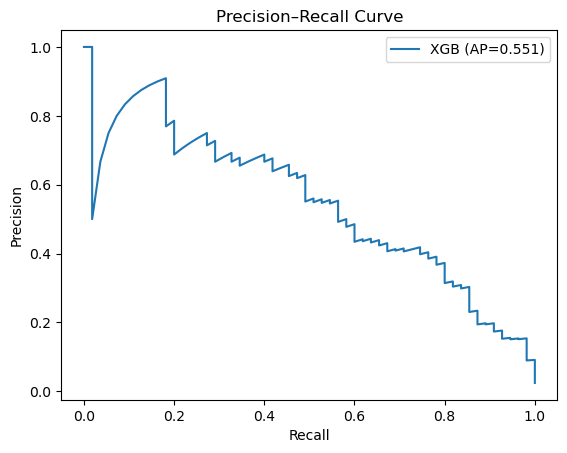

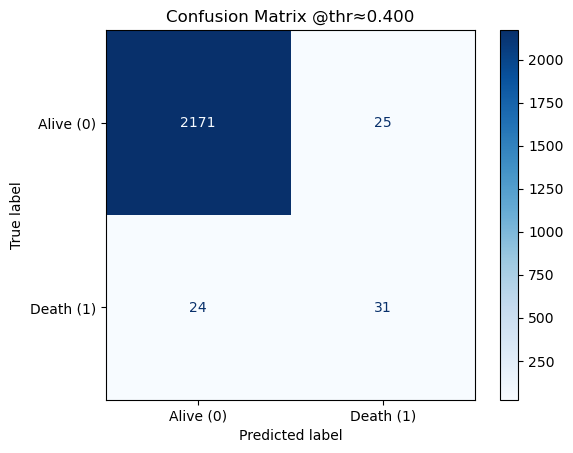

In [ ]:
# preprocessing
prep = clone(preprocessor).fit(train_df)
X_tr_enc = prep.transform(train_df)
X_va_enc = prep.transform(test_df)

# balance positive and negative weights to handle class imbalance 
pos, neg = (y_train == 1).sum(), (y_train == 0).sum()
# calculate scale pos weight as ratio of negative to positive samples
spw = neg / max(pos, 1)

# define model with best parameters from hyperparameter tuning
xgb_best = XGBClassifier(
    objective="binary:logistic", # binary classification
    tree_method="hist", # use histogram-based algorithm for faster training
    eval_metric="aucpr", # use AUC-PR as eval metric for imbalanced data
    random_state=42, # for reproducibility
    verbosity=0, #silent printing messages 
    **best_params # unpack best parameters dictionary
).set_params(scale_pos_weight=spw)

# fit model
xgb_best.fit(X_tr_enc, y_train, eval_set=[(X_va_enc, y_test)], verbose=False)


proba = xgb_best.predict_proba(X_va_enc)[:, 1] # predicted probabilities for positive class
auc_roc = roc_auc_score(y_test, proba) # AUC-ROC score
auc_pr  = average_precision_score(y_test, proba) # AUC-PR score

P, R, T = precision_recall_curve(y_test, proba) # precision, recall, thresholds for different probability cutoffs
if len(T) > 0: # if there are any thresholds
    f1s = 2 * (P[:-1] * R[:-1]) / np.clip(P[:-1] + R[:-1], 1e-12, None) # f1 scores for each threshold
    thr = T[np.argmax(f1s)] # threshold that gives highest f1 score
else:
    thr = 0.5 # default threshold if no thresholds available

pred = (proba >= thr).astype(int) # predicted labels based on threshold
f1 = f1_score(y_test, pred) # f1 score

# print metrics to 3 decimal places
print(f"AUC-ROC={auc_roc:.3f}  AUCPR={auc_pr:.3f}  F1@thr={f1:.3f} (thr≈{thr:.3f})")

# visualise metrics
# roc curve
fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure()
plt.plot(fpr, tpr, label=f'XGB (AUC={auc_roc:.3f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# precision recall curve
plt.figure()
plt.plot(R, P, label=f'XGB (AP={auc_pr:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.show()

# confusion matrix
cm = confusion_matrix(y_test, pred, labels=[0,1])
ConfusionMatrixDisplay(cm, display_labels=["Alive (0)","Death (1)"]).plot(
    values_format="d", cmap="Blues"
)
plt.title(f"Confusion Matrix @thr≈{thr:.3f}")
plt.show()

In [ ]:
### Prediction of Length of Stay (Regression) ###

# define feature columns
id_cols = ["subject_id", "hadm_id"]  # keep but don't use as features

# define numeric, categorical, and sequence columns
numeric_cols = [
    "age_at_admission", "ed_duration",
    "is_weekend", "is_night_admit",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos", "mon_sin", "mon_cos",
    "admission_index",
    "days_since_prev_admission", "days_since_first_admission",
    "num_prior_admissions", "has_prior_admission",
    "ccs_seq_len",
]
categorical_cols = [
    "gender", "admission_type", "admission_location",
    "insurance", "marital_status", "race",
]
sequence_col = ['ccs_seq'] # single column, but ColumnTransformer expects a list

# target column
target_col = "admission_duration"   # your LOS target (assumed in days)
# groups for test train split to prevent data leakage
groups = df["subject_id"].values

# define feature matrix and target vector
X = df[numeric_cols + categorical_cols].copy()
y = df[target_col].astype(float).values


In [ ]:
# Build preprocessing pipeline
# one hot encoding for categorical variables
cat_pipe = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

# skip for numeric variables, they just need to be scaled
num_pipe = 'passthrough'  # keep as-is

# multilabelbinarizer for ccs sequence column
seq_pipe = Pipeline(steps=[
    ('mlb', MLBBinarizer(missing_literal='MISSING'))
])

# combine all preprocessing steps for each type of data
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_cols),
        ('num', num_pipe, numeric_cols),
        ('seq', seq_pipe, sequence_col),
    ],
    remainder='drop',
    sparse_threshold=0.3
)

In [ ]:
# define feature matrix, target vector, and groups for stratified split 
X_los = df[numeric_cols + categorical_cols + sequence_col]
y_los = df["admission_duration"].astype(float).values
groups = df["subject_id"].values

# define model and parameters
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1500, learning_rate=0.03, max_depth=6,
    subsample=0.9, colsample_bytree=0.9, tree_method="hist", random_state=42
)

# pipeline (preprocessing and model)
pipe = Pipeline([("prep", preprocessor), ("xgb", xgb_reg)])

# Collapse to patient-level labels for stratified split
patient_labels = (
    df.groupby("subject_id")["hospital_expire_flag"]
      .max()  # if any admission flagged death, mark as 1
      .reset_index()
)

# get X and y for stratified split
X = patient_labels["subject_id"]
y = patient_labels["hospital_expire_flag"]

# Stratified split by patient_id and label
train_ids, test_ids, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures same proportion of outcome classes
)

# Assign admissions back to splits
X_tr = df[df["subject_id"].isin(train_ids)]
X_va = df[df["subject_id"].isin(test_ids)]
y_tr = df[df["subject_id"].isin(train_ids)]['admission_duration']
y_va = df[df["subject_id"].isin(test_ids)]['admission_duration']   

# empty list to store metrics
rows = []

# fit model and evaluate
pipe.fit(X_tr, y_tr)
pred = pipe.predict(X_va)

# calculate and store metrics
rows.append({
    "fold": fold,
    "MAE": mean_absolute_error(y_va, pred),
    "RMSE": np.sqrt(mean_squared_error(y_va, pred)),
    "R2": r2_score(y_va, pred),
})

los_cv = pd.DataFrame(rows)
los_cv

c:\Users\amydu\anaconda3\envs\uob_interview_env\Lib\site-packages\sklearn\preprocessing\_label.py:909: UserWarning: unknown class(es) ['INJ062', 'INJ063', 'MBD027', 'NEO001', 'NEO036', 'NEO059', 'NEO067'] will be ignored
  warnings.warn(


,fold,MAE,RMSE,R2
0,5,2.523333,5.25726,0.388417


MAE:  2.5233
RMSE: 5.2573   (MSE: 27.6388)
R²:   0.3884
MAPE: 132.02%   sMAPE: 55.55%
Pearson r:  0.6242 (p=2.21e-243)
Spearman ρ: 0.7357 (p=0.00e+00)
MAE by true-LOS decile: [0.912 1.317 1.623 1.996 1.586 1.685 1.95  2.078 3.041 9.052]


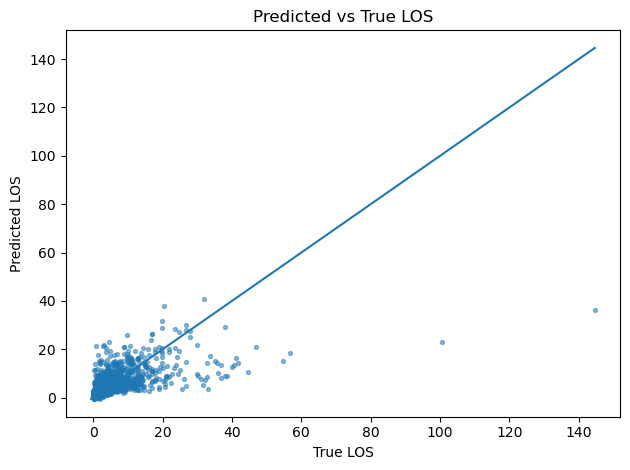

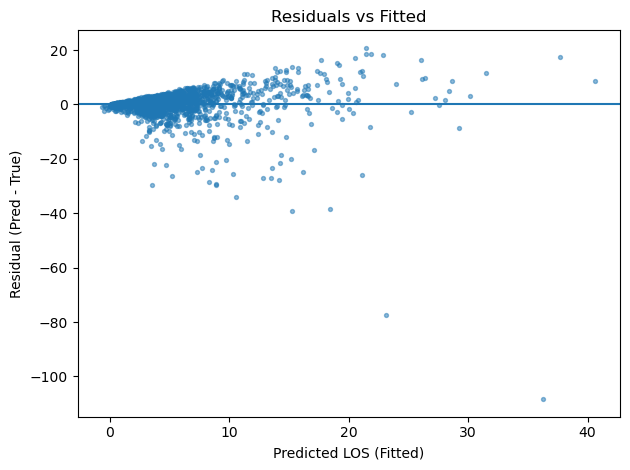

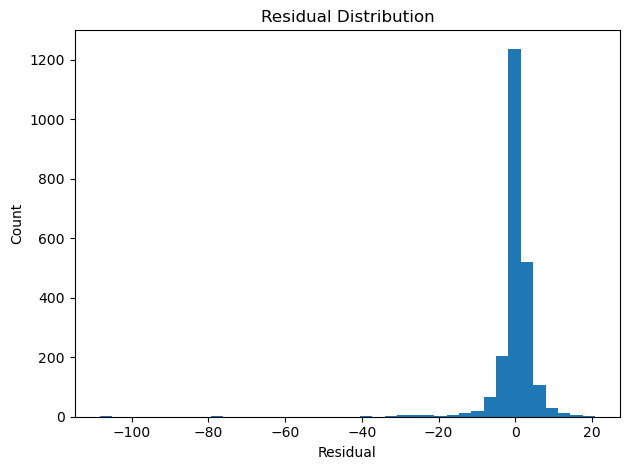

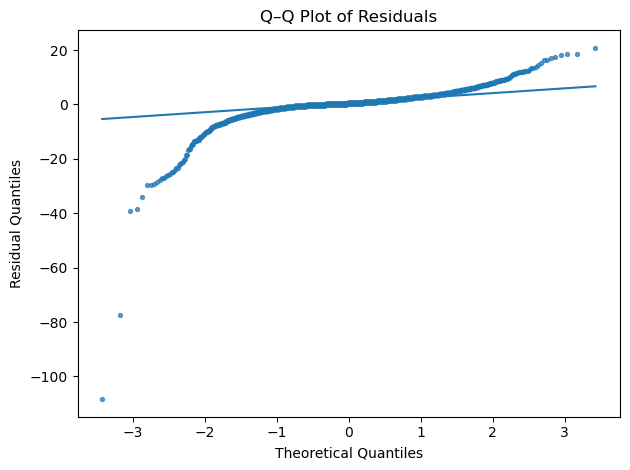

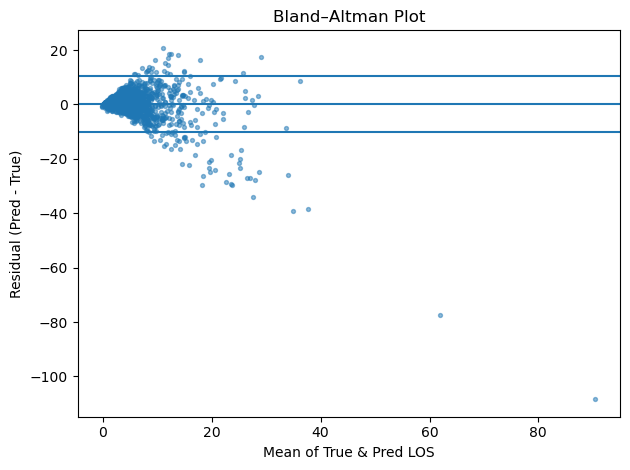

In [ ]:
y_pred = pred
resid  = y_pred - y_true  # calculate residuals

# --------- Metrics ----------
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_pred - y_true) / np.clip(y_true, 1e-8, None))) * 100.0  # avoid div by zero
r2   = r2_score(y_true, y_pred)

# Rank correlations are robust to outliers / monotonicity checks
pearson_r, pearson_p = stats.pearsonr(y_true, y_pred)
spearman_r, spearman_p = stats.spearmanr(y_true, y_pred)

# Symmetric mean absolute percentage error (less biased when values are small)
smape = 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1e-8))

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}   (MSE: {mse:.4f})")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%   sMAPE: {smape:.2f}%")
print(f"Pearson r:  {pearson_r:.4f} (p={pearson_p:.2e})")
print(f"Spearman ρ: {spearman_r:.4f} (p={spearman_p:.2e})")

# Optional: error by magnitude (deciles of true LOS)
quantiles = np.quantile(y_true, np.linspace(0, 1, 11))
bin_idx = np.digitize(y_true, quantiles[1:-1], right=True)
bin_mae = [np.mean(np.abs(resid[bin_idx==b])) for b in range(10)]
print("MAE by true-LOS decile:", np.round(bin_mae, 3))

# --------- Plots ----------
# 1) Predicted vs True (ideal line y=x)
plt.figure()
plt.scatter(y_true, y_pred, s=8, alpha=0.5)
minv, maxv = np.min([y_true.min(), y_pred.min()]), np.max([y_true.max(), y_pred.max()])
plt.plot([minv, maxv], [minv, maxv])
plt.xlabel("True LOS")
plt.ylabel("Predicted LOS")
plt.title("Predicted vs True LOS")
plt.tight_layout()
plt.show()

# 2) Residuals vs Fitted (check bias/heteroscedasticity)
plt.figure()
plt.scatter(y_pred, resid, s=8, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted LOS (Fitted)")
plt.ylabel("Residual (Pred - True)")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

# 3) Residual histogram (approx normality / skew)
plt.figure()
plt.hist(resid, bins=40)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

# 4) Q–Q plot of residuals (normality check)
osm, osr = stats.probplot(resid, dist="norm")  # returns theoretical & ordered responses
theoretical_q = osm[0]; ordered_resid = osm[1]
plt.figure()
plt.scatter(theoretical_q, ordered_resid, s=8, alpha=0.7)
# Reference line through quartiles
q1, q3 = np.percentile(ordered_resid, [25, 75])
tq1, tq3 = np.percentile(theoretical_q, [25, 75])
slope = (q3 - q1) / (tq3 - tq1 + 1e-12)
intercept = q1 - slope * tq1
xline = np.linspace(theoretical_q.min(), theoretical_q.max(), 100)
plt.plot(xline, slope * xline + intercept)
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Residual Quantiles")
plt.title("Q–Q Plot of Residuals")
plt.tight_layout()
plt.show()

# 5) Bland–Altman (agreement; useful when units matter)
avg = 0.5 * (y_true + y_pred)
plt.figure()
plt.scatter(avg, resid, s=8, alpha=0.5)
m = np.mean(resid); sd = np.std(resid, ddof=1)
for k in [-1.96, 0, 1.96]:
    plt.axhline(m + k*sd)
plt.xlabel("Mean of True & Pred LOS")
plt.ylabel("Residual (Pred - True)")
plt.title("Bland–Altman Plot")
plt.tight_layout()
plt.show()